Task 1: Apply Principal Component Analysis (PCA) for feature extraction and dimensionality reduction

Subtask 1.1: Data Acquisition and Feature Standardization

In [7]:
import warnings

In [8]:
warnings.filterwarnings("ignore")

In [9]:
import pandas as pd

In [10]:
import numpy as np

In [11]:
from sklearn.datasets import load_iris

In [12]:
from sklearn.preprocessing import StandardScaler


In [13]:
raw_iris = load_iris()

In [14]:
features = raw_iris.feature_names

In [15]:
X_raw = raw_iris.data

In [16]:
y_true = raw_iris.target

In [17]:
scaler = StandardScaler()

In [18]:
X_scaled = scaler.fit_transform(X_raw)

In [19]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [20]:
iris_df['species_id'] = y_true

In [21]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [22]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)

In [23]:
print("Standardized dataset dimensions:", X_scaled.shape)

Standardized dataset dimensions: (150, 4)


In [24]:
print("\nFirst 3 rows of standardized dataset:")


First 3 rows of standardized dataset:


In [25]:
print(iris_df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


Subtask 1.2: Covariance Matrix and Eigenvalue Decomposition

In [26]:
cov_matrix = np.cov(X_scaled.T)

In [27]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [28]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [29]:
print("\nEigenvalues (Variance components):\n", eigenvalues)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [30]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)


Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


Subtask 1.3: Implementing Dimensionality Reduction via PCA

In [31]:
from sklearn.decomposition import PCA

In [32]:
pca_model = PCA(n_components=2, random_state=42)

In [33]:
X_pca = pca_model.fit_transform(X_scaled)

In [34]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [35]:
pca_df['species_name'] = iris_df['species_name']

In [36]:
print("Transformed PCA space dimensions:", X_pca.shape)

Transformed PCA space dimensions: (150, 2)


In [37]:
print("\nFirst 3 projected coordinates:")


First 3 projected coordinates:


In [38]:
print(pca_df.head(3))

       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


Subtask 1.4: Visualizing the 2D PCA Feature Space

In [39]:
import matplotlib.pyplot as plt

In [40]:
import seaborn as sns

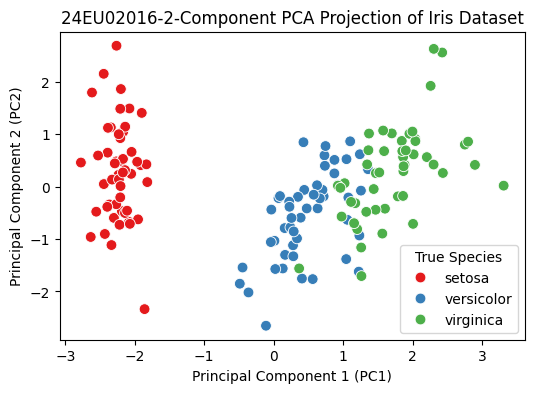

In [143]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("24EU02016-2-Component PCA Projection of Iris Dataset")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

Subtask 1.5: Analyzing Explained Variance Ratio

In [42]:
explained_variance = pca_model.explained_variance_ratio_

In [43]:
cumulative_variance = np.sum(explained_variance)

In [44]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [45]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")


  PC1: 72.96%
  PC2: 22.85%


In [46]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [47]:
import numpy as np

In [48]:
import pandas as pd

In [49]:
import matplotlib.pyplot as plt

In [50]:
from sklearn.datasets import load_iris

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
from sklearn.decomposition import PCA

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [56]:
# ============================================================
# Step 2: Load the Dataset
# ============================================================

iris = load_iris()

In [57]:
X = iris.data

In [58]:
y = iris.target

In [59]:
feature_names = iris.feature_names

In [60]:
target_names = iris.target_names

In [61]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [62]:
print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [63]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [64]:
# ============================================================
# Step 3: Split the Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [65]:
# ============================================================
# Step 4: Feature Scaling
# ============================================================

scaler = StandardScaler()


In [66]:
X_train_scaled = scaler.fit_transform(X_train)

In [67]:
X_test_scaled = scaler.transform(X_test)

In [68]:
# ============================================================
# PART A: CLASSIFICATION WITHOUT PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")


CLASSIFICATION WITHOUT PCA


In [69]:
# Create Logistic Regression model
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [70]:
# Train the model
model_without_pca.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [71]:
# Predict test data
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [72]:
# Calculate accuracy
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)


In [73]:
print("Accuracy without PCA:",
      accuracy_without_pca)

Accuracy without PCA: 0.9333333333333333


In [74]:
print("\nClassification Report:")


Classification Report:


In [75]:
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [76]:
# ============================================================
# PART B: CLASSIFICATION WITH PCA
# ============================================================

print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")



CLASSIFICATION WITH PCA


In [77]:
# Apply PCA
pca = PCA(
    n_components=2
)


In [78]:
# Fit PCA only on training data
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [79]:
# Transform test data using the same PCA
X_test_pca = pca.transform(
    X_test_scaled
)

In [80]:
# Display explained variance
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)


Explained Variance Ratio: [0.72677234 0.23066667]


In [81]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


Total Explained Variance: 0.9574390106545363


In [82]:
# Create Logistic Regression model
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [83]:
# Train the model using PCA features
model_with_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [84]:
# Predict test data
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

In [85]:
# Calculate accuracy
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)


In [86]:
print("Accuracy with PCA:",
      accuracy_with_pca)


Accuracy with PCA: 0.9


In [87]:

print("\nClassification Report:")


Classification Report:


In [88]:
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [89]:
# ============================================================
# PART C: COMPARE BOTH MODELS
# ============================================================

print("\n========================================")
print("COMPARISON")
print("========================================")


COMPARISON


In [90]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})


In [91]:
print(comparison)

        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


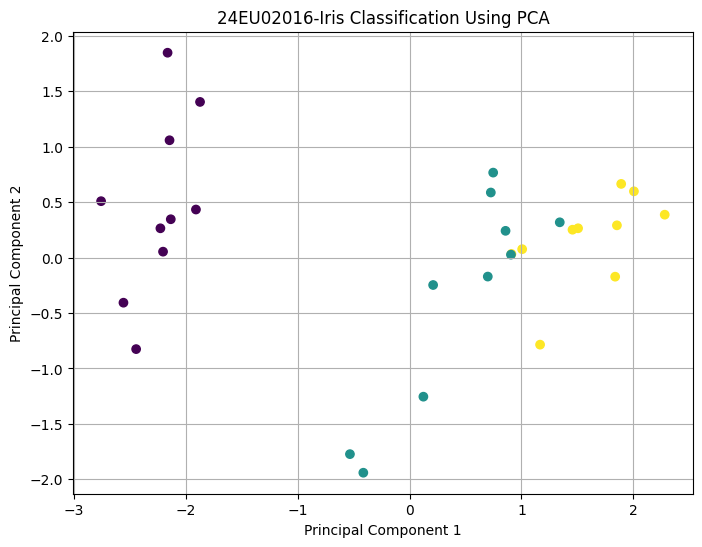

In [92]:
# ============================================================
# PART D: VISUALIZE PCA FEATURES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("24EU02016-Iris Classification Using PCA")
plt.grid()

plt.show()

Task 2: Design clustering models using K-Means clustering for pattern discovery and data grouping

Subtask 2.1: Determining Clusters via the Elbow Method (WCSS)

In [93]:
import warnings

In [94]:
warnings.filterwarnings("ignore")

In [95]:
from sklearn.cluster import KMeans

In [96]:
import matplotlib.pyplot as plt

In [97]:
wcss = []

In [98]:
k_range = range(1, 11)

In [99]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

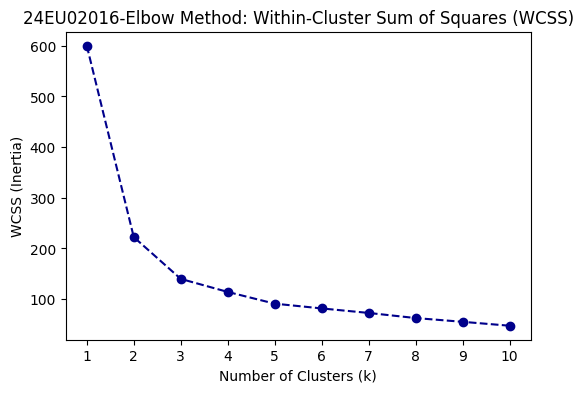

In [100]:
# Plot the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("24EU02016-Elbow Method: Within-Cluster Sum of Squares (WCSS)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()


Subtask 2.2: Validating Optimal Clusters with Silhouette Analysis

In [101]:
from sklearn.metrics import silhouette_score

In [102]:
silhouette_scores = []

In [103]:
k_eval = range(2, 6)

In [104]:
# Calculate silhouette scores for different cluster counts
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)


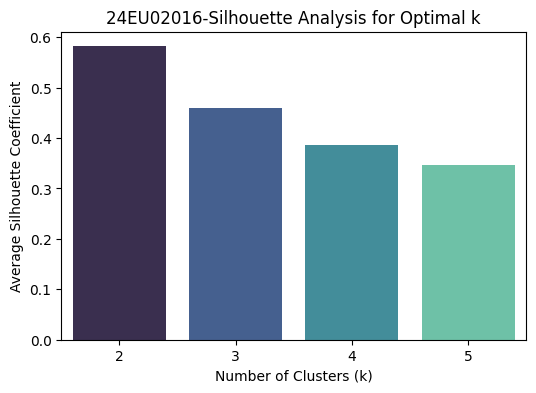

In [105]:
# Plot Silhouette scores
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("24EU02016-Silhouette Analysis for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()


In [106]:
# Find and print the best k
best_k = k_eval[np.argmax(silhouette_scores)]

In [107]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")

k = 2 yielded the highest silhouette coefficient (0.5818).


Subtask 2.3: Implementing K-Means Clustering on the Raw Feature Space

In [108]:
# Train K-Means on the standardized raw 4D feature space
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [109]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [110]:
# Append cluster labels to main DataFrame
iris_df['cluster_raw'] = kmeans_raw_labels

In [111]:
print("K-Means clustering complete. First 5 sample allocations:")

K-Means clustering complete. First 5 sample allocations:


In [112]:
print(iris_df[['species_name', 'cluster_raw']].head(5))


  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


Subtask 2.4: Extracting and Inspecting Cluster Centroids

In [113]:
# Extract raw centroid coordinates in standardized space
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [114]:
# Inverse transform centroids back to original physical measurements (cm)
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [115]:
# Store in a summary table
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)

In [116]:
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

In [117]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")

--- Estimated Cluster Centroids (Original Physical Units - cm) ---


In [118]:
print(centroids_df)

           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


Subtask 2.5: Visualizing Raw Clusters and Centroids

In [119]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [120]:
# Convert standardized centroids to original units for plotting
raw_data = scaler.inverse_transform(X_scaled)

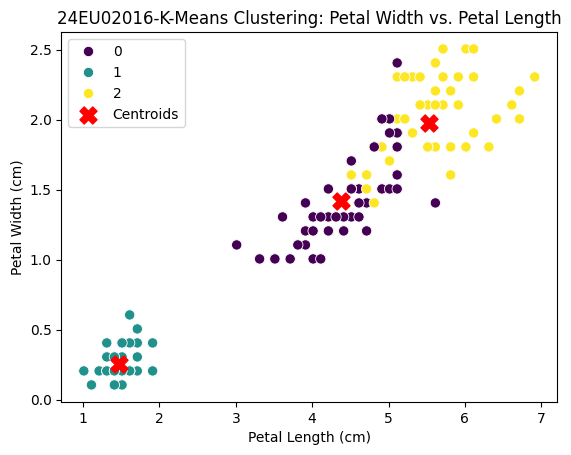

In [121]:
# Plot the continuous data points colored by cluster assignment
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')
# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2],
    raw_centroids_physical[:, 3],
    color='red',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title("24EU02016-K-Means Clustering: Petal Width vs. Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

Task 3: Analyze clustering performance and compare transformed feature spaces for improved data interpretation

Subtask 3.1: K-Means Clustering in the PCA-Reduced Space

In [122]:
import warnings

In [123]:
warnings.filterwarnings("ignore")

In [124]:
from sklearn.cluster import KMeans

In [125]:

# Train a separate K-Means model on the 2-Component PCA space
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [126]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [127]:
# Append to main DataFrame
iris_df['cluster_pca'] = kmeans_pca_labels

In [128]:
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


Subtask 3.2: Internal Validation Metrics (Silhouette and Calinski-Harabasz Scores)

In [129]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [130]:
# Compute internal metrics for raw space clusters
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)

In [131]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)

In [132]:
# Compute internal metrics for PCA-reduced space clusters
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)

In [133]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [134]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")

--- Internal Validation (Unsupervised Quality Metrics) ---


In [135]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")

Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [136]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")

PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


Subtask 3.3: Faceted Visual Comparison: K-Means Clusters vs. True Species

In [137]:
import matplotlib.pyplot as plt

In [138]:
import seaborn as sns

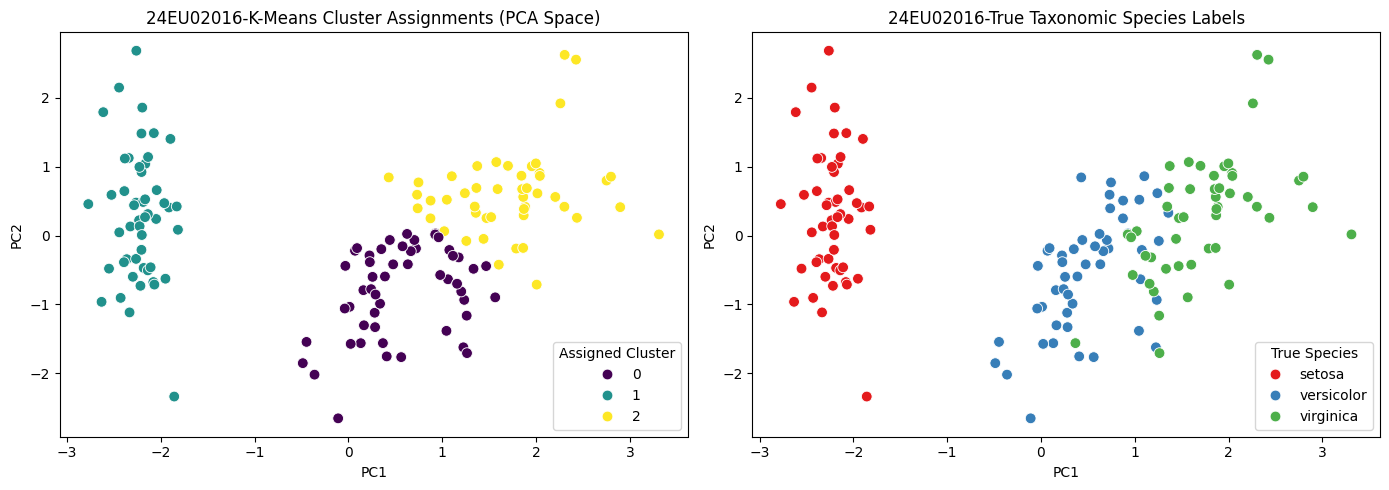

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels,
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("24EU02016-K-Means Cluster Assignments (PCA Space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name',
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("24EU02016-True Taxonomic Species Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()


Subtask 3.4: Compiling the Performance Comparison Table

In [142]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari_raw = adjusted_rand_score(y_true, kmeans_raw_labels)
nmi_raw = normalized_mutual_info_score(y_true, kmeans_raw_labels)
# PCA-reduced space metrics
ari_pca = adjusted_rand_score(y_true, kmeans_pca_labels)
nmi_pca = normalized_mutual_info_score(y_true, kmeans_pca_labels)
# Compile metrics into a comparison DataFrame
comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)
print("--- Clustering Performance Summary: Raw vs. PCA ---")
print(comparison_metrics.round(4))

--- Clustering Performance Summary: Raw vs. PCA ---
                             Silhouette_Score  Calinski_Harabasz  \
Standardized Raw Space (4D)            0.4599           241.9044   
PCA Reduced Space (2D)                 0.5092           293.8565   

                             Adjusted_Rand_Index  Normalized_Mutual_Info  
Standardized Raw Space (4D)               0.6201                  0.6595  
PCA Reduced Space (2D)                    0.6201                  0.6595  
